# 4-Hour Hands-on Tutorial: Artificial Neural Network Using Deep Learning

## Project: Customer Churn Prediction using ANN

You are working as a junior deep learning engineer for a telecom company. The business wants to predict whether a customer is likely to leave the company or continue using the service.

This Google Colab notebook is self-contained. It creates a synthetic telecom churn dataset, performs preprocessing, builds an ANN model, evaluates it, improves it using Dropout and EarlyStopping, saves the model, and predicts churn for a new customer.

## Learning Outcomes

By the end of this 4-hour tutorial, learners will be able to:

1. Explain ANN in simple terms.
2. Understand neurons, layers, weights, bias, activation functions, loss, optimizer, epochs, batch size, and learning rate.
3. Generate and understand a binary classification dataset.
4. Handle numerical and categorical data.
5. Build preprocessing pipelines.
6. Build, train, evaluate, and improve an ANN using TensorFlow/Keras.
7. Save and reuse a trained ANN model.
8. Make prediction for a new customer.

## 4-Hour Agenda

| Time | Module | Focus |
|---|---|---|
| 0:00 - 0:25 | Module 1 | ANN theory and business problem |
| 0:25 - 0:55 | Module 2 | Dataset creation and understanding |
| 0:55 - 1:25 | Module 3 | Exploratory data analysis |
| 1:25 - 1:55 | Module 4 | Data preprocessing |
| 1:55 - 2:35 | Module 5 | Build and train first ANN |
| 2:35 - 3:05 | Module 6 | Model evaluation |
| 3:05 - 3:35 | Module 7 | Improve ANN using Dropout and EarlyStopping |
| 3:35 - 3:50 | Module 8 | Save model and make new prediction |
| 3:50 - 4:00 | Module 9 | Assignment and viva questions |

# Module 1: ANN Concept in Layman Terms

ANN stands for **Artificial Neural Network**.

A neural network is made of small calculation units called **neurons**. These neurons are arranged in layers.

```text
Input Layer  →  Hidden Layers  →  Output Layer
```

## Customer Churn Example

Input data:

- Monthly charges
- Tenure
- Data usage
- Support calls
- Contract type
- Payment method

The ANN learns patterns like:

```text
High monthly charge + low tenure + many support calls = high churn chance
```

## Important Terms

| Term | Meaning |
|---|---|
| Neuron | Small calculation unit |
| Weight | Importance of input |
| Bias | Adjustment value |
| Hidden layer | Learns internal patterns |
| Activation function | Adds non-linearity |
| Epoch | One full pass over training data |
| Batch size | Number of records processed at once |
| Learning rate | Speed of learning |
| Loss | Model error |
| Optimizer | Updates weights to reduce error |

# Module 2: Environment Setup

Run this cell in Google Colab. TensorFlow is usually pre-installed, but this makes sure all required packages are available.

In [1]:
!pip -q install pandas numpy matplotlib scikit-learn tensorflow joblib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("Libraries imported successfully")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully
TensorFlow version: 2.20.0


# Module 3: Create Synthetic Customer Churn Dataset

We will create a realistic telecom churn dataset.

## Target Variable

```text
Churn
```

| Value | Meaning |
|---|---|
| 0 | Customer will not churn |
| 1 | Customer will churn |

This is a **binary classification problem**.

In [3]:
np.random.seed(42)

n = 5000

age = np.random.randint(18, 75, n)
tenure_months = np.random.randint(1, 73, n)
monthly_charges = np.round(np.random.normal(70, 25, n), 2)
monthly_charges = np.clip(monthly_charges, 20, 150)

data_usage_gb = np.round(np.random.gamma(shape=4, scale=12, size=n), 2)
support_calls = np.random.poisson(lam=2, size=n)
late_payments = np.random.poisson(lam=1, size=n)

contract_type = np.random.choice(
    ["Month-to-month", "One year", "Two year"],
    size=n,
    p=[0.55, 0.30, 0.15]
)

internet_service = np.random.choice(
    ["Fiber optic", "DSL", "No internet"],
    size=n,
    p=[0.50, 0.35, 0.15]
)

payment_method = np.random.choice(
    ["Electronic check", "Credit card", "Bank transfer", "Mailed check"],
    size=n,
    p=[0.40, 0.25, 0.25, 0.10]
)

gender = np.random.choice(["Male", "Female"], size=n)

# Business logic for churn probability
churn_score = (
    -0.035 * tenure_months
    + 0.025 * monthly_charges
    + 0.35 * support_calls
    + 0.40 * late_payments
    + 0.90 * (contract_type == "Month-to-month").astype(int)
    + 0.45 * (payment_method == "Electronic check").astype(int)
    + 0.35 * (internet_service == "Fiber optic").astype(int)
    - 2.8
)

churn_probability = 1 / (1 + np.exp(-churn_score))
churn = np.random.binomial(1, churn_probability)

df = pd.DataFrame({
    "Age": age,
    "Tenure_Months": tenure_months,
    "Monthly_Charges": monthly_charges,
    "Data_Usage_GB": data_usage_gb,
    "Support_Calls": support_calls,
    "Late_Payments": late_payments,
    "Contract_Type": contract_type,
    "Internet_Service": internet_service,
    "Payment_Method": payment_method,
    "Gender": gender,
    "Churn": churn
})

df.head()

,Age,Tenure_Months,Monthly_Charges,Data_Usage_GB,Support_Calls,Late_Payments,Contract_Type,Internet_Service,Payment_Method,Gender,Churn
0,56,9,49.78,46.20,4,3,Month-to-month,DSL,Credit card,Female,0
1,69,37,117.24,18.09,1,0,Month-to-month,Fiber optic,Electronic check,Male,1
2,46,36,59.74,46.82,1,0,Month-to-month,Fiber optic,Electronic check,Male,1
3,32,28,73.63,39.35,2,1,One year,Fiber optic,Electronic check,Male,0
4,60,42,102.58,56.06,4,1,Month-to-month,No internet,Mailed check,Male,1


## Add Missing Values

Real-world data often contains missing values. We intentionally add missing values to selected columns so that students can practice missing value treatment.

In [4]:
missing_columns = ["Monthly_Charges", "Data_Usage_GB", "Contract_Type", "Payment_Method"]

for col in missing_columns:
    missing_indices = np.random.choice(df.index, size=int(0.03 * n), replace=False)
    df.loc[missing_indices, col] = np.nan

df.isnull().sum()

,0
Age,0
Tenure_Months,0
Monthly_Charges,150
Data_Usage_GB,150
Support_Calls,0
Late_Payments,0
Contract_Type,150
Internet_Service,0
Payment_Method,150
Gender,0


# Student Task 1

Answer:

1. What is the target variable?
2. Is this classification or regression?
3. Which columns are numerical?
4. Which columns are categorical?
5. Why can churn prediction help a telecom company?

### Student Task 1 - Answers

1. **What is the target variable?**
   The target variable is `Churn`.

2. **Is this classification or regression?**
   This is a **binary classification** problem because we are predicting a discrete outcome: whether a customer will leave (1) or stay (0).

3. **Which columns are numerical?**
   Based on the dataset generation and `df.info()`, the numerical columns are: `Age`, `Tenure_Months`, `Monthly_Charges`, `Data_Usage_GB`, `Support_Calls`, and `Late_Payments`.

4. **Which columns are categorical?**
   The categorical columns are: `Contract_Type`, `Internet_Service`, `Payment_Method`, and `Gender`.

5. **Why can churn prediction help a telecom company?**
   Churn prediction helps the company identify 'at-risk' customers before they leave. This allows the business to take proactive measures, such as offering discounts, improved service plans, or personalized outreach, to retain the customer, which is generally much cheaper than acquiring a new one.

# Module 4: Exploratory Data Analysis

EDA means understanding the dataset before building the model.

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 5000
Columns: 11


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               5000 non-null   int64  
 1   Tenure_Months     5000 non-null   int64  
 2   Monthly_Charges   4850 non-null   float64
 3   Data_Usage_GB     4850 non-null   float64
 4   Support_Calls     5000 non-null   int64  
 5   Late_Payments     5000 non-null   int64  
 6   Contract_Type     4850 non-null   object 
 7   Internet_Service  5000 non-null   object 
 8   Payment_Method    4850 non-null   object 
 9   Gender            5000 non-null   object 
 10  Churn             5000 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 429.8+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,46.148600,16.325753,18.00,32.0000,46.000,60.0000,74.00
Tenure_Months,5000.0,36.875800,20.770524,1.00,19.0000,37.000,55.0000,72.00
Monthly_Charges,4850.0,70.097697,24.541926,20.00,52.7300,70.110,86.7275,150.00
Data_Usage_GB,4850.0,47.939625,23.711079,3.83,30.4625,43.925,61.1450,166.99
Support_Calls,5000.0,2.005200,1.434149,0.00,1.0000,2.000,3.0000,10.00
Late_Payments,5000.0,1.008800,1.004850,0.00,0.0000,1.000,2.0000,6.00
Churn,5000.0,0.435200,0.495833,0.00,0.0000,0.000,1.0000,1.00


In [8]:
df["Churn"].value_counts()

,count
Churn,
0,2824
1,2176


In [9]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0,56.48
1,43.52


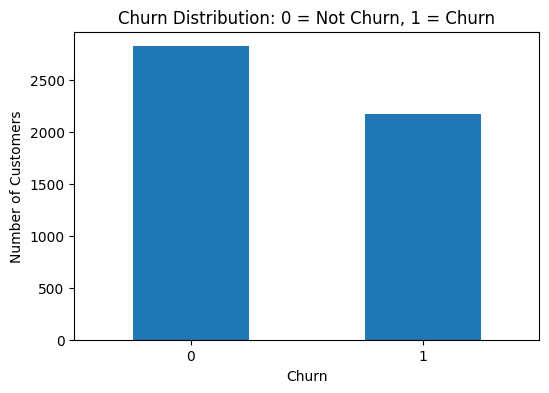

In [10]:
plt.figure(figsize=(6, 4))
df["Churn"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Churn Distribution: 0 = Not Churn, 1 = Churn")
plt.xticks(rotation=0)
plt.show()

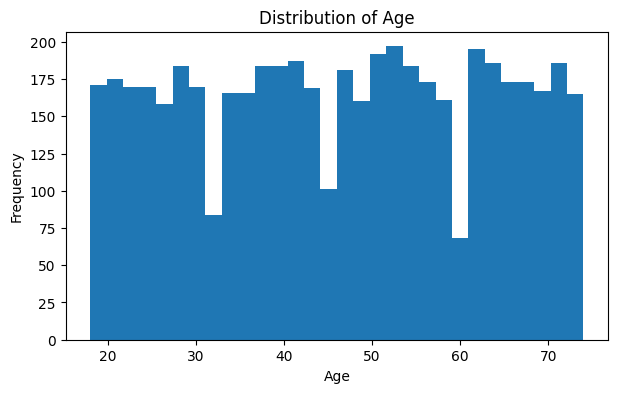

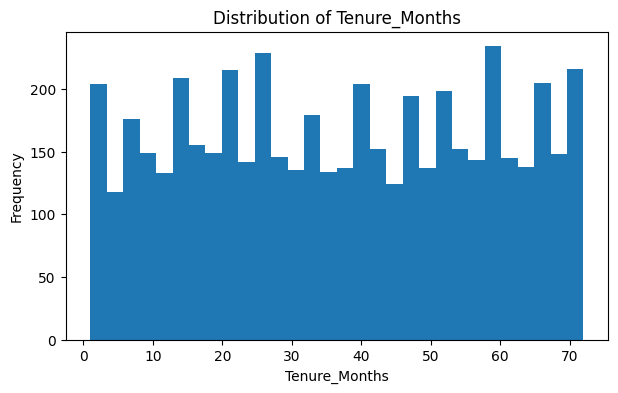

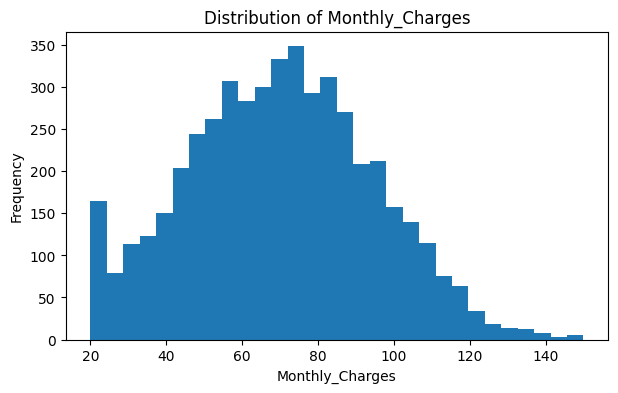

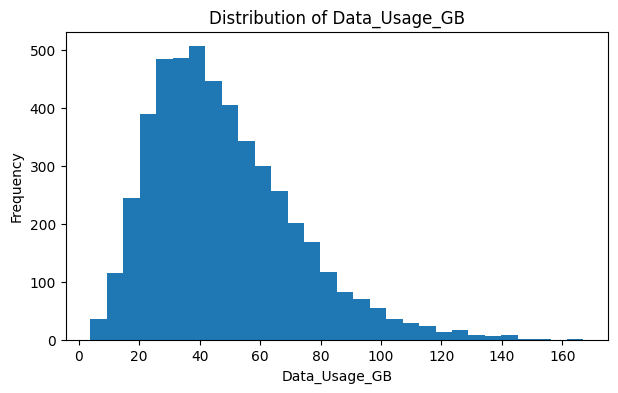

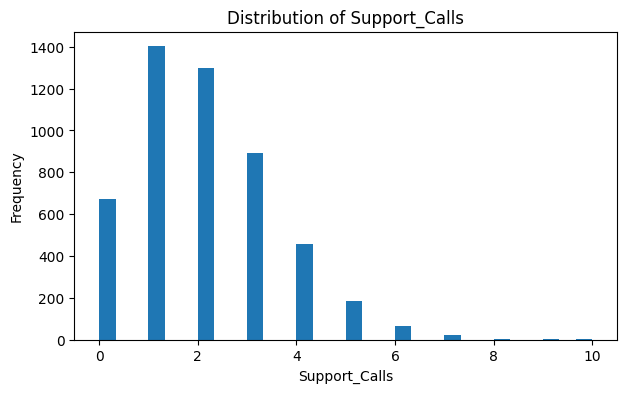

In [11]:
for col in ["Age", "Tenure_Months", "Monthly_Charges", "Data_Usage_GB", "Support_Calls"]:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.show()

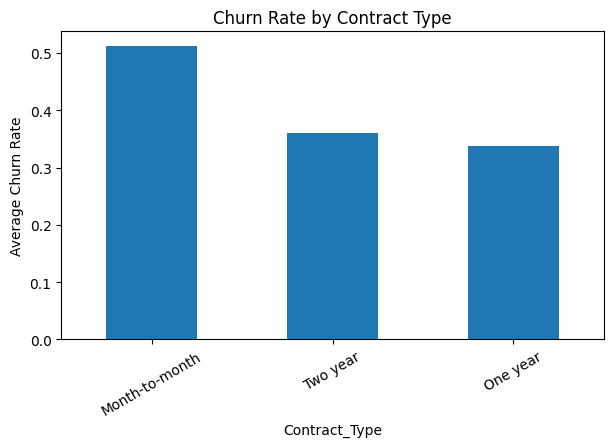

,Churn
Contract_Type,
Month-to-month,0.512092
Two year,0.360700
One year,0.337550


In [12]:
contract_churn = df.groupby("Contract_Type")["Churn"].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
contract_churn.plot(kind="bar")
plt.ylabel("Average Churn Rate")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=30)
plt.show()

contract_churn

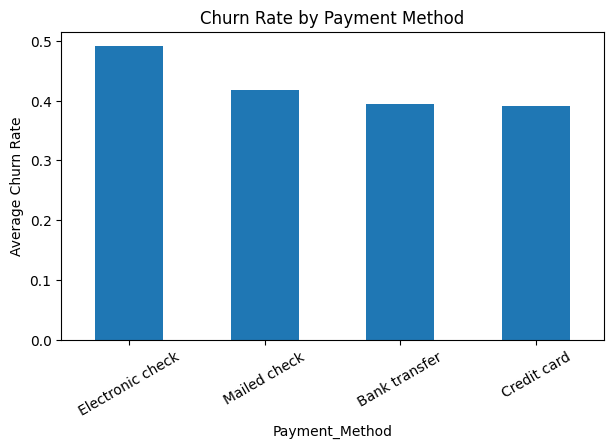

,Churn
Payment_Method,
Electronic check,0.490518
Mailed check,0.417323
Bank transfer,0.393496
Credit card,0.391042


In [13]:
payment_churn = df.groupby("Payment_Method")["Churn"].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
payment_churn.plot(kind="bar")
plt.ylabel("Average Churn Rate")
plt.title("Churn Rate by Payment Method")
plt.xticks(rotation=30)
plt.show()

payment_churn

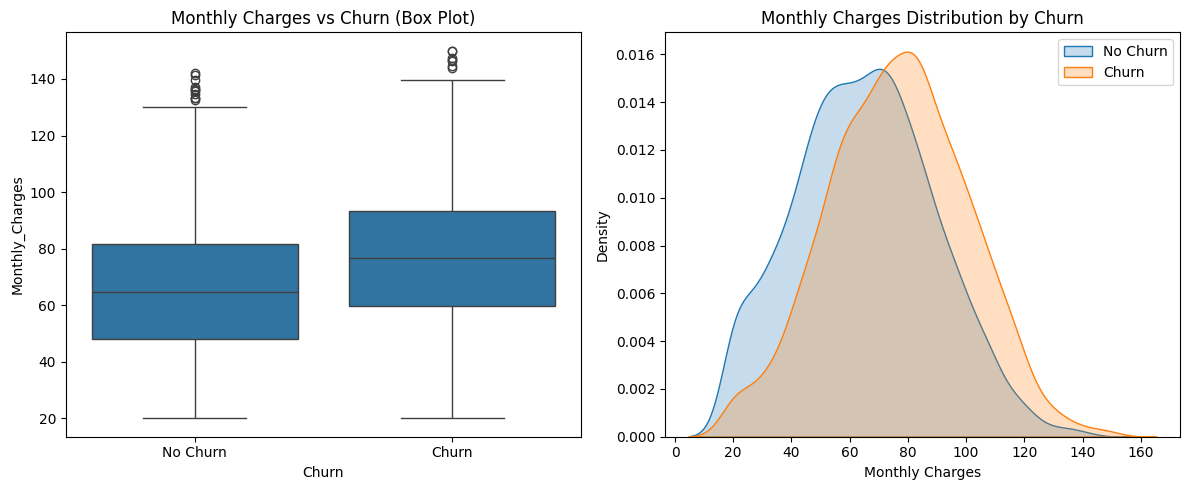

In [42]:
import seaborn as sns

plt.figure(figsize=(12, 5))

# Subplot 1: Box Plot
plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='Monthly_Charges', data=df)
plt.title('Monthly Charges vs Churn (Box Plot)')
plt.xticks([0, 1], ['No Churn', 'Churn'])

# Subplot 2: KDE Plot (Distribution)
plt.subplot(1, 2, 2)
sns.kdeplot(df[df['Churn'] == 0]['Monthly_Charges'].dropna(), label='No Churn', fill=True)
sns.kdeplot(df[df['Churn'] == 1]['Monthly_Charges'].dropna(), label='Churn', fill=True)
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.legend()

plt.tight_layout()
plt.show()

# Module 5: Data Preparation for ANN

ANN models need numerical input. So we will:

1. Separate features and target.
2. Split data into training and testing sets.
3. Fill missing numerical values.
4. Scale numerical values.
5. Fill missing categorical values.
6. One-hot encode categorical values.

In [14]:
target = "Churn"

X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5000, 10)
Target shape: (5000,)


In [15]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: ['Age', 'Tenure_Months', 'Monthly_Charges', 'Data_Usage_GB', 'Support_Calls', 'Late_Payments']
Categorical Features: ['Contract_Type', 'Internet_Service', 'Payment_Method', 'Gender']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Train churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Training rows: 4000
Testing rows: 1000
Train churn rate: 0.43525
Test churn rate: 0.435


## Build Preprocessing Pipeline

For ANN, scaling numerical features is important because neural networks learn better when input values are on a similar scale.

In [17]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created")

Preprocessing pipeline created


In [18]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (4000, 18)
Processed testing shape: (1000, 18)


# Student Task 2

Answer:

1. Why do we use train-test split?
2. Why do we use stratify in classification?
3. Why do we scale numerical columns before ANN?
4. Why do we one-hot encode categorical columns?
5. Why do we fit the preprocessor only on training data?

### Student Task 2 - Answers

1. **Why do we use train-test split?**
   We split the data to evaluate our model's performance on unseen data. If we trained and tested on the same data, we wouldn't know if the model actually learned patterns or just memorized the training examples (overfitting).

2. **Why do we use stratify in classification?**
   Stratification ensures that the proportion of the target classes (Churn vs. No Churn) remains the same in both the training and testing sets as it is in the original dataset. This prevents the model from being biased if one set accidentally gets significantly more examples of a specific class.

3. **Why do we scale numerical columns before ANN?**
   Neural Networks use Gradient Descent to update weights. If one feature has a range of 0-1 and another has 0-1000, the gradients will be unbalanced, making the training process very slow or unstable. Scaling (like `StandardScaler`) puts all features on a similar scale (e.g., mean 0, variance 1).

4. **Why do we one-hot encode categorical columns?**
   ANNs are mathematical models that only understand numbers. Categorical text (like "Fiber optic") must be converted into numerical vectors. One-hot encoding represents each category as a binary column, preventing the model from assuming an incorrect mathematical order between categories (e.g., assuming 'Fiber' > 'DSL').

5. **Why do we fit the preprocessor only on training data?**
   We only `fit` on training data to prevent **Data Leakage**. If we use the mean or standard deviation of the entire dataset (including the test set), information from the 'future' (the test set) leaks into the training process, leading to over-optimistic and unrealistic performance metrics.

# Module 6: Build First ANN Model

Architecture:

```text
Input Layer
    ↓
Dense Layer with ReLU
    ↓
Dense Layer with ReLU
    ↓
Output Layer with Sigmoid
```

Since churn prediction is binary classification, the output layer uses **sigmoid** activation.

In [19]:
np.random.seed(42)
tf.random.set_seed(42)

input_dim = X_train_processed.shape[1]

ann_model = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

## ANN Code Explanation

| Code | Meaning |
|---|---|
| `Input(shape=(input_dim,))` | Number of input features after preprocessing |
| `Dense(64, activation="relu")` | Hidden layer with 64 neurons |
| `Dense(32, activation="relu")` | Hidden layer with 32 neurons |
| `Dense(1, activation="sigmoid")` | Output layer for binary classification |
| `binary_crossentropy` | Loss function for binary classification |
| `Adam` | Optimizer to update weights |
| `learning_rate=0.001` | Speed of learning |

In [20]:
history = ann_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=40,
    batch_size=32,
    verbose=1
)

Epoch 1/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6556 - loss: 0.6199 - val_accuracy: 0.7262 - val_loss: 0.5727
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7200 - loss: 0.5591 - val_accuracy: 0.7113 - val_loss: 0.5636
Epoch 3/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7281 - loss: 0.5492 - val_accuracy: 0.7113 - val_loss: 0.5618
Epoch 4/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7319 - loss: 0.5444 - val_accuracy: 0.7150 - val_loss: 0.5610
Epoch 5/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7341 - loss: 0.5409 - val_accuracy: 0.7262 - val_loss: 0.5609
Epoch 6/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7341 - loss: 0.5377 - val_accuracy: 0.7262 - val_loss: 0.5607
Epoch 7/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7356 - loss: 0.5347 - val_accuracy: 0.7237 - val_loss: 0.5609
Epoch 8/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7378 - loss: 0.5321 - val_accuracy

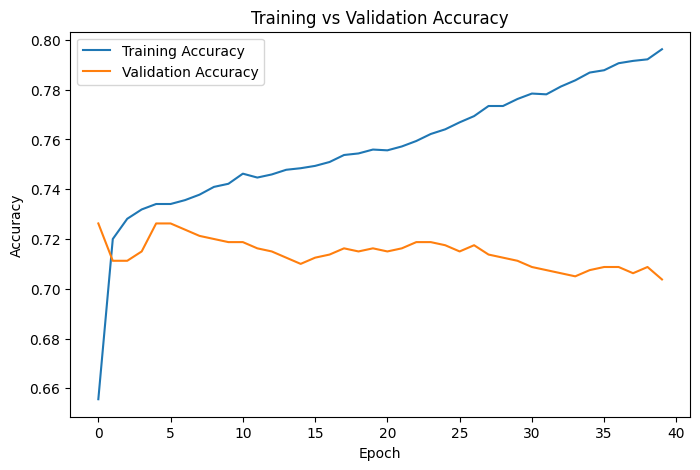

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

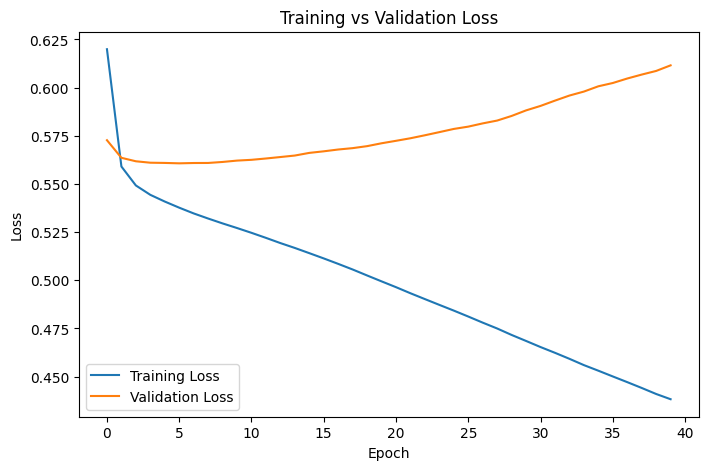

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Module 7: Evaluate ANN Model

We will evaluate the model using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- Classification Report
- ROC Curve

In [23]:
y_pred_proba = ann_model.predict(X_test_processed).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("ANN Model Evaluation")
print("--------------------")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
ANN Model Evaluation
--------------------
Accuracy: 0.681
Precision: 0.6324
Recall: 0.6368
F1 Score: 0.6346
ROC-AUC: 0.7424


In [24]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[404, 161],
       [158, 277]])

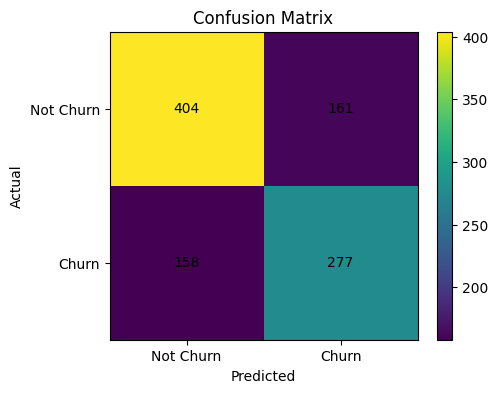

In [25]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Not Churn", "Churn"])
plt.yticks([0, 1], ["Not Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [26]:
print(classification_report(y_test, y_pred, target_names=["Not Churn", "Churn"]))

              precision    recall  f1-score   support

   Not Churn       0.72      0.72      0.72       565
       Churn       0.63      0.64      0.63       435

    accuracy                           0.68      1000
   macro avg       0.68      0.68      0.68      1000
weighted avg       0.68      0.68      0.68      1000



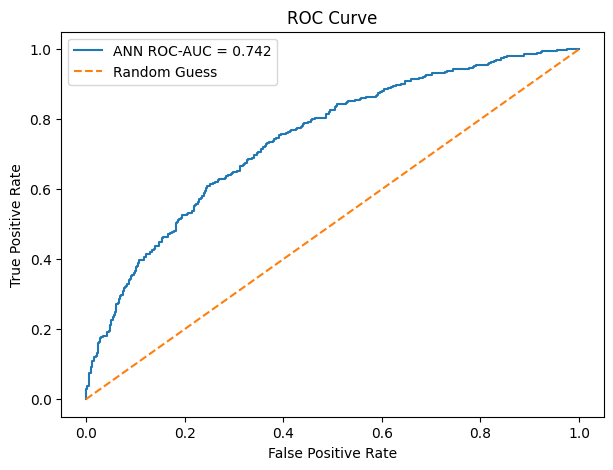

In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ANN ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Module 8: Improve ANN using Dropout and EarlyStopping

## Overfitting

Overfitting means the model performs well on training data but poorly on unseen testing data.

## Dropout

Dropout randomly switches off some neurons during training.

Layman meaning:

```text
The model should not depend too much on only a few neurons.
```

## EarlyStopping

EarlyStopping stops training when validation loss stops improving.

Layman meaning:

```text
Stop training before the model starts memorizing the data.
```

In [28]:
np.random.seed(42)
tf.random.set_seed(42)

improved_ann_model = Sequential([
    Input(shape=(input_dim,)),
    Dense(128, activation="relu"),
    Dropout(0.30),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

improved_ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

improved_ann_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
improved_history = improved_ann_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=80,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6325 - loss: 0.6317 - val_accuracy: 0.6963 - val_loss: 0.5797
Epoch 2/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7119 - loss: 0.5696 - val_accuracy: 0.7075 - val_loss: 0.5703
Epoch 3/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7216 - loss: 0.5632 - val_accuracy: 0.7225 - val_loss: 0.5648
Epoch 4/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7237 - loss: 0.5565 - val_accuracy: 0.7125 - val_loss: 0.5657
Epoch 5/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7250 - loss: 0.5521 - val_accuracy: 0.7150 - val_loss: 0.5670
Epoch 6/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7278 - loss: 0.5481 - val_accuracy: 0.7175 - val_loss: 0.5656
Epoch 7/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7262 - loss: 0.5476 - val_accuracy: 0.7237 - val_loss: 0.5665
Epoch 8/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7253 - loss: 0.5497 - val_accuracy: 0.

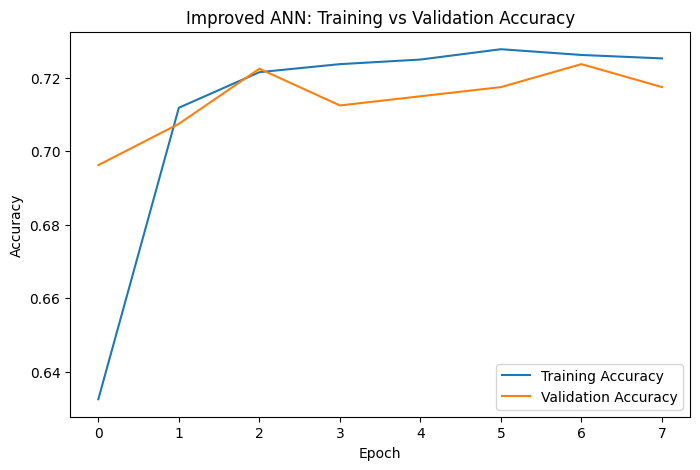

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(improved_history.history["accuracy"], label="Training Accuracy")
plt.plot(improved_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved ANN: Training vs Validation Accuracy")
plt.legend()
plt.show()

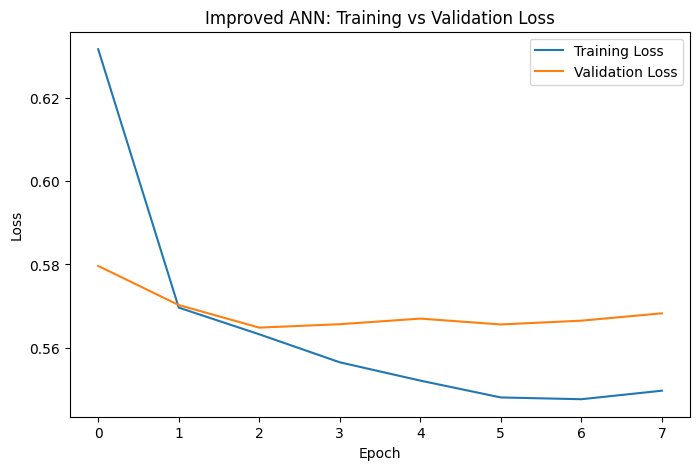

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(improved_history.history["loss"], label="Training Loss")
plt.plot(improved_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved ANN: Training vs Validation Loss")
plt.legend()
plt.show()

In [32]:
improved_pred_proba = improved_ann_model.predict(X_test_processed).ravel()
improved_pred = (improved_pred_proba >= 0.5).astype(int)

improved_accuracy = accuracy_score(y_test, improved_pred)
improved_precision = precision_score(y_test, improved_pred)
improved_recall = recall_score(y_test, improved_pred)
improved_f1 = f1_score(y_test, improved_pred)
improved_roc_auc = roc_auc_score(y_test, improved_pred_proba)

print("Improved ANN Model Evaluation")
print("-----------------------------")
print("Accuracy:", round(improved_accuracy, 4))
print("Precision:", round(improved_precision, 4))
print("Recall:", round(improved_recall, 4))
print("F1 Score:", round(improved_f1, 4))
print("ROC-AUC:", round(improved_roc_auc, 4))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Improved ANN Model Evaluation
-----------------------------
Accuracy: 0.712
Precision: 0.6674
Recall: 0.6736
F1 Score: 0.6705
ROC-AUC: 0.7792


In [43]:
from sklearn.metrics import classification_report

# Generate classification report for the improved model
print("Classification Report: Improved ANN Model")
print("------------------------------------------")
print(classification_report(y_test, improved_pred, target_names=['Not Churn', 'Churn']))

Classification Report: Improved ANN Model
------------------------------------------
              precision    recall  f1-score   support

   Not Churn       0.75      0.74      0.74       565
       Churn       0.67      0.67      0.67       435

    accuracy                           0.71      1000
   macro avg       0.71      0.71      0.71      1000
weighted avg       0.71      0.71      0.71      1000



In [33]:
comparison_df = pd.DataFrame([
    {
        "Model": "Simple ANN",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    },
    {
        "Model": "Improved ANN",
        "Accuracy": improved_accuracy,
        "Precision": improved_precision,
        "Recall": improved_recall,
        "F1 Score": improved_f1,
        "ROC-AUC": improved_roc_auc
    }
])

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Simple ANN,0.681,0.632420,0.636782,0.634593,0.742378
1,Improved ANN,0.712,0.667426,0.673563,0.670481,0.779188


# Module 9: Threshold Tuning

By default, a customer is classified as churn if probability is greater than or equal to 0.5.

Businesses can choose a different threshold.

- Lower threshold catches more churn customers.
- Higher threshold gives fewer but more confident churn predictions.

In [34]:
threshold_results = []

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_threshold = (improved_pred_proba >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, pred_threshold),
        "Precision": precision_score(y_test, pred_threshold),
        "Recall": recall_score(y_test, pred_threshold),
        "F1 Score": f1_score(y_test, pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.3,0.623,0.540503,0.889655,0.672459
1,0.4,0.684,0.605310,0.786207,0.684000
2,0.5,0.712,0.667426,0.673563,0.670481
3,0.6,0.713,0.718935,0.558621,0.628719
4,0.7,0.681,0.787129,0.365517,0.499215


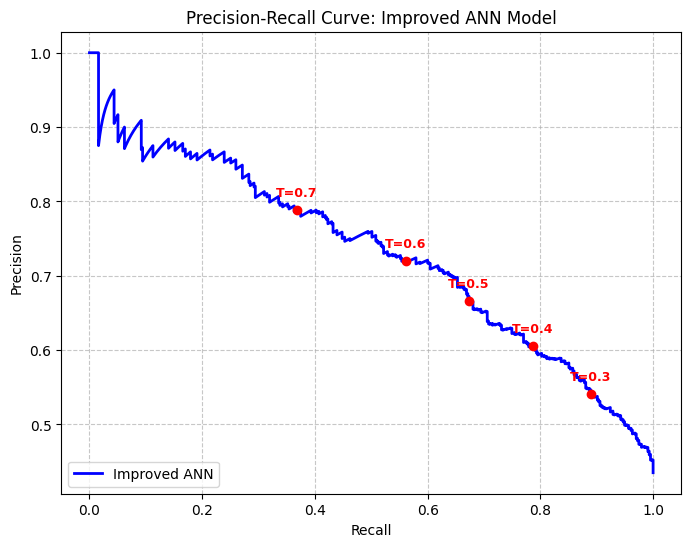

In [44]:
from sklearn.metrics import precision_recall_curve

# Calculate precision and recall for all possible thresholds
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, improved_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='blue', lw=2, label='Improved ANN')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Improved ANN Model')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower left')

# Mark specific thresholds from our previous analysis
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    # Find the index of the closest threshold in the PR curve data
    idx = np.argmin(np.abs(thresholds_pr - t))
    plt.annotate(f'T={t}', (recalls[idx], precisions[idx]),
                 textcoords="offset points", xytext=(0,10), ha='center',
                 fontsize=9, color='red', weight='bold')
    plt.plot(recalls[idx], precisions[idx], 'ro')

plt.show()

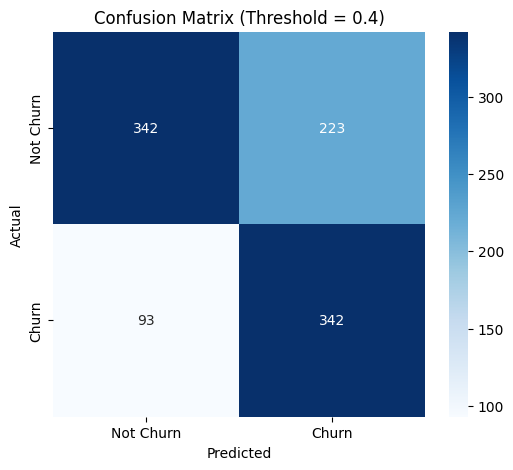

--- Metrics at T=0.4 ---
Recall:    0.7862
Precision: 0.6053
Accuracy:  0.6840


In [45]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate predictions using the 0.4 threshold
y_pred_04 = (improved_pred_proba >= 0.4).astype(int)

# Create confusion matrix
cm_04 = confusion_matrix(y_test, y_pred_04)

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm_04, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix (Threshold = 0.4)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Print metrics for this specific threshold
print(f"--- Metrics at T=0.4 ---")
print(f"Recall:    {recall_score(y_test, y_pred_04):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_04):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_04):.4f}")

# Module 10: Save and Reuse ANN Model

We save:

1. The preprocessing pipeline
2. The trained ANN model

Why both?

The model expects processed/scaled/encoded data. So every new customer must go through the same preprocessor.

In [35]:
joblib.dump(preprocessor, "ann_churn_preprocessor.pkl")
improved_ann_model.save("ann_churn_model.keras")

print("Preprocessor and ANN model saved successfully")

Preprocessor and ANN model saved successfully


In [36]:
loaded_preprocessor = joblib.load("ann_churn_preprocessor.pkl")
loaded_model = tf.keras.models.load_model("ann_churn_model.keras")

print("Model and preprocessor loaded successfully")

Model and preprocessor loaded successfully


# Module 11: New Customer Prediction

In [37]:
new_customer = pd.DataFrame({
    "Age": [35],
    "Tenure_Months": [6],
    "Monthly_Charges": [105.50],
    "Data_Usage_GB": [85.20],
    "Support_Calls": [5],
    "Late_Payments": [3],
    "Contract_Type": ["Month-to-month"],
    "Internet_Service": ["Fiber optic"],
    "Payment_Method": ["Electronic check"],
    "Gender": ["Female"]
})

new_customer

,Age,Tenure_Months,Monthly_Charges,Data_Usage_GB,Support_Calls,Late_Payments,Contract_Type,Internet_Service,Payment_Method,Gender
0,35,6,105.5,85.2,5,3,Month-to-month,Fiber optic,Electronic check,Female


In [38]:
new_customer_processed = loaded_preprocessor.transform(new_customer)

if hasattr(new_customer_processed, "toarray"):
    new_customer_processed = new_customer_processed.toarray()

new_customer_probability = loaded_model.predict(new_customer_processed).ravel()[0]
new_customer_prediction = 1 if new_customer_probability >= 0.5 else 0

print("Churn Probability:", round(new_customer_probability, 4))
print("Predicted Class:", new_customer_prediction)

if new_customer_prediction == 1:
    print("Business Interpretation: Customer is likely to churn.")
else:
    print("Business Interpretation: Customer is not likely to churn.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Churn Probability: 0.956
Predicted Class: 1
Business Interpretation: Customer is likely to churn.


# Module 12: Student Assignment

## Assignment 1: Change ANN Architecture

Try these architectures:

1. 32 → 16 → 1
2. 128 → 64 → 32 → 1
3. 256 → 128 → 64 → 1

Record:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

## Assignment 2: Change Dropout

Try dropout values:

```text
0.1, 0.2, 0.3, 0.5
```

Observe whether overfitting reduces.

## Assignment 3: Threshold Selection

Try thresholds:

```text
0.25, 0.35, 0.45, 0.55, 0.65
```

Which threshold gives the best precision-recall balance?

## Assignment 4: Business Interpretation

Write a short business explanation:

1. Which customers are more likely to churn?
2. Which metric is most important for churn prediction?
3. How can the telecom company use this model?

### Assignment 1: Change ANN Architecture
We will test three different hidden layer structures and compare their metrics.

In [39]:
def build_and_train_ann(layers, dropout_rate=0.0):
    model = Sequential([Input(shape=(input_dim,))])
    for units in layers:
        model.add(Dense(units, activation='relu'))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train_processed, y_train, epochs=30, batch_size=32, verbose=0)

    probs = model.predict(X_test_processed).ravel()
    preds = (probs >= 0.5).astype(int)

    return {
        "Architecture": " -> ".join(map(str, layers)),
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    }

architectures = [[32, 16], [128, 64, 32], [256, 128, 64]]
arch_results = [build_and_train_ann(arch) for arch in architectures]
arch_df = pd.DataFrame(arch_results)
display(arch_df)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


,Architecture,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,32 -> 16,0.687,0.635556,0.657471,0.646328,0.753331
1,128 -> 64 -> 32,0.632,0.563089,0.687356,0.619048,0.686518
2,256 -> 128 -> 64,0.603,0.533688,0.691954,0.602603,0.673708


### Assignment 2: Change Dropout
We will evaluate how different dropout values affect the model using the [128, 64, 32] architecture.

In [40]:
dropout_values = [0.1, 0.2, 0.3, 0.5]
dropout_results = []

for d in dropout_values:
    res = build_and_train_ann([128, 64, 32], dropout_rate=d)
    res['Dropout'] = d
    dropout_results.append(res)

dropout_df = pd.DataFrame(dropout_results)
display(dropout_df)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Architecture,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Dropout
0,128 -> 64 -> 32,0.656,0.590818,0.680460,0.632479,0.721343,0.1
1,128 -> 64 -> 32,0.695,0.647727,0.655172,0.651429,0.752676,0.2
2,128 -> 64 -> 32,0.698,0.644880,0.680460,0.662192,0.754308,0.3
3,128 -> 64 -> 32,0.698,0.659472,0.632184,0.645540,0.760883,0.5


### Assignment 3: Threshold Selection
We will evaluate the best performing model from Assignment 2 at different probability thresholds.

In [41]:
thresholds = [0.25, 0.35, 0.45, 0.55, 0.65]
t_results = []

# Using the improved_pred_proba from previous module execution
for t in thresholds:
    p_class = (improved_pred_proba >= t).astype(int)
    t_results.append({
        "Threshold": t,
        "Precision": precision_score(y_test, p_class),
        "Recall": recall_score(y_test, p_class),
        "F1-Score": f1_score(y_test, p_class)
    })

t_df = pd.DataFrame(t_results)
display(t_df)

,Threshold,Precision,Recall,F1-Score
0,0.25,0.513274,0.933333,0.662316
1,0.35,0.582677,0.850575,0.691589
2,0.45,0.635815,0.726437,0.678112
3,0.55,0.703046,0.636782,0.668275
4,0.65,0.750916,0.471264,0.579096


### Assignment 4: Business Interpretation

1. **Which customers are more likely to churn?**
   Customers with high monthly charges, many support calls, frequent late payments, and those on month-to-month contracts are significantly more likely to churn.

2. **Which metric is most important for churn prediction?**
   **Recall** is typically the most important. It measures how many of the actual churners we correctly identified. Missing a churner (False Negative) is usually more expensive for a telecom than misidentifying a loyal customer (False Positive).

3. **How can the telecom company use this model?**
   - **Proactive Retention:** Offer targeted discounts to customers with high churn probabilities.
   - **Customer Feedback:** Reach out to high-risk customers who have many support calls to resolve issues before they leave.
   - **Financial Planning:** Predict future revenue loss by estimating churn volumes.

# Viva Questions

1. What is an Artificial Neural Network?
2. What is a neuron?
3. What is the role of weights and bias?
4. Why do we use activation functions?
5. Why is ReLU used in hidden layers?
6. Why is sigmoid used in the output layer?
7. What is binary crossentropy?
8. What is an optimizer?
9. What is learning rate?
10. What is an epoch?
11. What is batch size?
12. What is overfitting?
13. How does Dropout reduce overfitting?
14. What is EarlyStopping?
15. Why do we scale numerical features before ANN?
16. What is ROC-AUC?
17. Why is recall important in churn prediction?
18. Why do we save the preprocessor along with the ANN model?

### Viva Questions - Answers

1. **What is an Artificial Neural Network?**
   An ANN is a computing system inspired by the biological neural networks of animal brains. It consists of interconnected units called neurons that learn to perform tasks by considering examples.

2. **What is a neuron?**
   A neuron is the basic mathematical unit of an ANN. It receives inputs, processes them (using weights, bias, and an activation function), and passes an output to the next layer.

3. **What is the role of weights and bias?**
   Weights determine the importance or 'strength' of an input signal. Bias is an additional parameter used to adjust the output along with the weighted sum of inputs to help the model better fit the data.

4. **Why do we use activation functions?**
   They introduce non-linearity into the network, allowing it to learn complex patterns. Without them, the ANN would behave like a simple linear regression model regardless of the number of layers.

5. **Why is ReLU used in hidden layers?**
   ReLU (Rectified Linear Unit) is computationally efficient and helps prevent the 'vanishing gradient' problem, allowing deeper networks to train faster.

6. **Why is sigmoid used in the output layer?**
   For binary classification, sigmoid squashes the output into a range between 0 and 1, which can be interpreted as a probability.

7. **What is binary crossentropy?**
   It is the standard loss function for binary classification. It measures the 'distance' between the predicted probability and the actual class (0 or 1).

8. **What is an optimizer?**
   An optimizer (like Adam) is an algorithm that updates the weights and biases of the network to minimize the loss function.

9. **What is learning rate?**
   It is a hyperparameter that controls how much the model's weights are adjusted in response to the estimated error each time the weights are updated.

10. **What is an epoch?**
    An epoch is one complete pass of the entire training dataset through the neural network.

11. **What is batch size?**
    The number of training examples utilized in one iteration to update the model weights.

12. **What is overfitting?**
    Overfitting occurs when a model learns the noise and details in the training data so well that it performs poorly on new, unseen data.

13. **How does Dropout reduce overfitting?**
    Dropout randomly ignores a subset of neurons during training, which prevents the network from becoming overly reliant on specific neurons and forces it to learn more robust features.

14. **What is EarlyStopping?**
    A technique that stops training as soon as the validation performance (like loss) starts to degrade, preventing the model from over-training on the training set.

15. **Why do we scale numerical features before ANN?**
    Scaling ensures all features contribute equally to the result and helps the optimizer converge (find the best weights) much faster.

16. **What is ROC-AUC?**
    ROC-AUC (Area Under the Receiver Operating Characteristic Curve) measures the model's ability to distinguish between classes. A higher AUC indicates a better performing model.

17. **Why is recall important in churn prediction?**
    Recall is vital because the cost of losing a customer (False Negative) is usually much higher than the cost of a retention campaign (False Positive). We want to catch as many potential churners as possible.

18. **Why do we save the preprocessor along with the ANN model?**
    The model was trained on processed/scaled data. To make accurate predictions on new 'raw' data, that data must be transformed exactly the same way as the training data.

# Final Summary

In this 4-hour hands-on tutorial, we built an end-to-end ANN project for customer churn prediction.

We learned:

```text
Raw data
→ EDA
→ Missing value handling
→ Scaling and encoding
→ ANN model building
→ Model training
→ Model evaluation
→ Dropout and EarlyStopping
→ Model saving
→ New customer prediction
```

Key takeaway:

> ANN is a deep learning model that learns patterns using neurons, weights, bias, activation functions, loss function, and optimizer. For tabular classification problems like churn prediction, ANN can learn useful non-linear relationships from customer data.